<a href="https://colab.research.google.com/github/samriddhisingh05/1BM23CS295_Samriddhi_Singh_ML_Lab/blob/main/1BM23CS295_Lab_8_AdaBoost_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.read_csv("income.csv")

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = LabelEncoder().fit_transform(data[col])

In [3]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
model = AdaBoostClassifier(n_estimators=10)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy (10 trees):", accuracy_score(y_test, y_pred))

Accuracy (10 trees): 0.8182004299314157


In [6]:
best_score = 0
best_n = 0

for n in [10, 20, 50, 100, 150, 200]:
    model = AdaBoostClassifier(n_estimators=n)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    print("n =", n, "Accuracy =", score)

    if score > best_score:
        best_score = score
        best_n = n

print("Best Score:", best_score)
print("Best n_estimators:", best_n)

n = 10 Accuracy = 0.8182004299314157
n = 20 Accuracy = 0.8244446719213839
n = 50 Accuracy = 0.8327362063670796
n = 100 Accuracy = 0.8328385709898659
n = 150 Accuracy = 0.8329409356126523
n = 200 Accuracy = 0.8332480294810114
Best Score: 0.8332480294810114
Best n_estimators: 200


Best Accuracy: 0.8334527587265841
Best n_estimators: 80


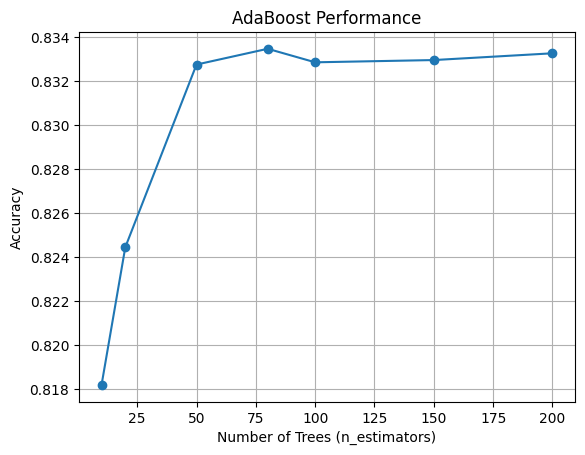

In [7]:
import matplotlib.pyplot as plt

estimators_range = [10, 20, 50, 80, 100, 150, 200]
scores = []

for n in estimators_range:
    model = AdaBoostClassifier(n_estimators=n)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    scores.append(score)

best_score = max(scores)
best_n = estimators_range[scores.index(best_score)]

print("Best Accuracy:", best_score)
print("Best n_estimators:", best_n)

plt.figure()
plt.plot(estimators_range, scores, marker='o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("AdaBoost Performance")
plt.grid()
plt.show()